# COG-sector plots from ME model solutions
This notebook generates **proteomics** and **transcriptomics** COG-sector plots (simulation vs experiment) for:
- **Glucose**
- **Acetate**
- **Glycerol**
- **Xylose**

## Key Inputs
- Experimental proteomics are mass fractions. Replicates will be averaged per gene.
- Experimental transcriptomics are TPM for each sample. Data is converted to a mass-fraction-like scale by dividing by 1,000,000.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams["figure.figsize"] = (6, 6)


## Input paths
Update paths below if needed.

In [2]:
# ---- Experimental data ----
PROTEOMICS_EXP = "proteomics.csv"      # Multiple replicates so columns like Glucose1.., Acetate1.. etc
TRANSCRIPT_TPM = "counts_TPM.csv"      # TPM for Acetate, Glucose, Glycerol, Xylose

# ---- COG letter mapping ----
COG_MAP = "cogs_ecoli_mg1655.csv"      # locus -> COG category primary (letter)

# ---- Molecular weights used for mass-fraction calculation from translation fluxes ----
MW_RNA_JSON  = "mw_rna.json" 
MW_PROT_JSON = "mw_prot.json"

# ---- Model solution dictionaries (x_dict) per substrate ----
XDICT_JSON = {
    "Glucose":  "substrate models/glucose.json",
    "Acetate":  "substrate models/acetate.json",
    "Glycerol": "substrate models/glycerol.json",
    "Xylose":   "substrate models/xylose.json",
}


## Helper functions

In [3]:
def load_json_dict(path):
    with open(path, "r") as f:
        return json.load(f)

def square_limits(x, y, pad=0.05):
    max_lim = float(np.nanmax([np.nanmax(x), np.nanmax(y)]))
    if not np.isfinite(max_lim) or max_lim <= 0:
        max_lim = 1.0
    return 0.0, max_lim * (1.0 + pad)

def get_exp_cols_by_prefix(df, prefix):
    p = prefix.lower()
    return [c for c in df.columns if c.lower().startswith(p)]

def get_total_transcriptome(x_dict, MW_dict_rna):
    total_transcriptome = 0.0
    mf_dict = {}
    if x_dict is None:
        raise ValueError("No feasible solution (x_dict is None)")

    for a, b in x_dict.items():
        if isinstance(a, str) and a.startswith("translation_") and b > 1e-20:
            gene = a.replace("translation_", "")
            flux = x_dict["translation_" + gene]
            mw = MW_dict_rna[gene]                 
            total_transcriptome += flux * mw
            mf_dict[gene] = flux * mw

    return total_transcriptome, mf_dict


def get_total_proteome(x_dict, MW_dict_prot):
    total_protein = 0.0
    mf_dict = {}
    if x_dict is None:
        raise ValueError("No feasible solution (x_dict is None)")

    for a, b in x_dict.items():
        if isinstance(a, str) and a.startswith("translation_") and b > 1e-20:
            gene = a.replace("translation_", "")
            flux = x_dict["translation_" + gene]
            mw = MW_dict_prot[gene]                
            total_protein += flux * mw
            mf_dict[gene] = flux * mw

    return total_protein, mf_dict


def mass_dict_to_fraction_df(total_mass, mass_dict):
    if total_mass <= 0:
        return pd.DataFrame(columns=["Gene", "Mass Fraction"])
    scaled = {g: m/total_mass for g, m in mass_dict.items()}
    return pd.DataFrame(list(scaled.items()), columns=["Gene", "Mass Fraction"])

def plot_cog_scatter(agg_df, cog_col, title, xlab, ylab, label_font=13):
    x = agg_df["sim_total"].values
    y = agg_df["exp_total"].values

    r = np.nan
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        r, _ = pearsonr(x, y)

    xmin, xmax = square_limits(x, y)

    plt.figure()
    plt.scatter(x, y)
    plt.xlim(xmin, xmax)
    plt.ylim(xmin, xmax)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)

    for _, row in agg_df.iterrows():
        plt.text(row["sim_total"], row["exp_total"], str(row[cog_col]),
                 fontsize=label_font, ha="center", va="center")

    if np.isfinite(r):
        plt.text(xmin + 0.02*(xmax-xmin), xmax - 0.05*(xmax-xmin),
                 f"Pearson r = {r:.2f}", fontsize=12, va="top")

    plt.show()
    return r


## Load mappings + experimental data

In [4]:
# COG mapping: locus -> COG letter
cog_map = (
    pd.read_csv(COG_MAP, encoding="cp1252")
      .rename(columns={"locus": "Gene", "COG category primary": "COG"})
      [["Gene", "COG"]]
)

# Molecular weights
MW_dict_rna  = load_json_dict(MW_RNA_JSON)
MW_dict_prot = load_json_dict(MW_PROT_JSON)

# Experimental proteomics
prot_exp = pd.read_csv(PROTEOMICS_EXP, sep="\t").rename(columns={"Unnamed: 0": "Gene"})

# Experimental transcriptomics (TPM is tab-separated)
tpm = pd.read_csv(TRANSCRIPT_TPM, sep="\t").rename(columns={"Geneid": "Gene"})
for c in ["Acetate", "Glucose", "Glycerol", "Xylose"]:
    tpm[c] = tpm[c] / 1_000_000.0


## Compute simulation mass fractions from x_dict (proteome + transcriptome)

In [5]:
sim_prot = {}
sim_tx = {}

for substrate, path in XDICT_JSON.items():
    x_dict = load_json_dict(path)

    # Transcript mass fractions (RNA MW)
    total_tx, mf_tx = get_total_transcriptome(x_dict, MW_dict_rna)
    sim_tx[substrate] = mass_dict_to_fraction_df(total_tx, mf_tx)

    # Proteome mass fractions (protein MW)
    total_p, mf_p = get_total_proteome(x_dict, MW_dict_prot)
    sim_prot[substrate] = mass_dict_to_fraction_df(total_p, mf_p)

## Proteomics plots (COG letters)

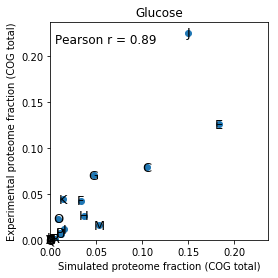

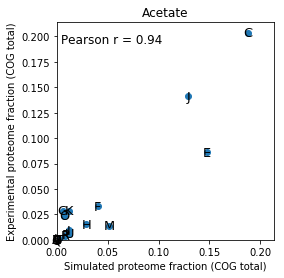

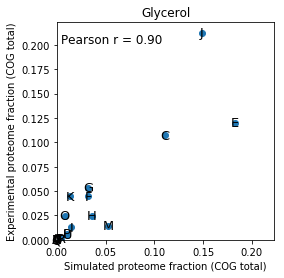

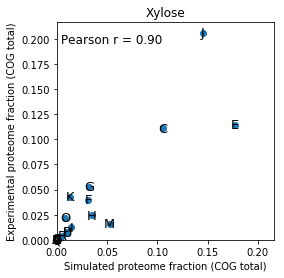

In [6]:
prot_summary = []

for substrate in ["Glucose", "Acetate", "Glycerol", "Xylose"]:
    sim = sim_prot[substrate].rename(columns={"Mass Fraction": "sim"})
    # Add COG letters
    sim = sim.merge(cog_map, on="Gene", how="left")
    sim["COG"] = sim["COG"].fillna("Unknown")
    sim = sim[sim["COG"].astype(str).str.lower() != "unknown"]

    # Experimental: average replicates per gene
    exp_cols = get_exp_cols_by_prefix(prot_exp, substrate)
    if len(exp_cols) == 0:
        raise ValueError(f"No experimental proteomics columns found for substrate prefix: {substrate}")

    exp_sub = (
        prot_exp[["Gene"] + exp_cols]
        .set_index("Gene")
        .mean(axis=1)
        .rename("exp")
        .reset_index()
    )
    # Add COG letters
    exp_sub = exp_sub.merge(cog_map, on="Gene", how="left")
    exp_sub["COG"] = exp_sub["COG"].fillna("Unknown")
    exp_sub = exp_sub[exp_sub["COG"].astype(str).str.lower() != "unknown"]

    # Intersection-only
    merged = exp_sub.merge(sim[["Gene", "COG", "sim"]], on=["Gene", "COG"], how="inner")

    # Aggregate by COG letter
    agg = (
        merged
        .groupby("COG", as_index=False)
        .agg({
            "exp": "sum",
            "sim": "sum"
        })
        .rename(columns={
            "exp": "exp_total",
            "sim": "sim_total"
        })
    )

    r = plot_cog_scatter(
        agg_df=agg,
        cog_col="COG",
        title=substrate,
        xlab="Simulated proteome fraction (COG total)",
        ylab="Experimental proteome fraction (COG total)",
        label_font=13,
    )

    prot_summary.append({"Substrate": substrate, "Pearson_r": r, "N_COGs": len(agg)})

# pd.DataFrame(prot_summary)


## Transcriptomics plots (COG letters)

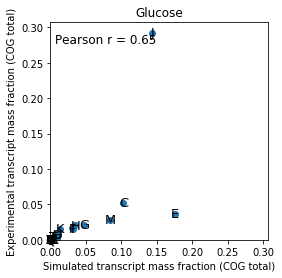

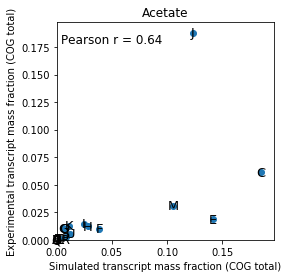

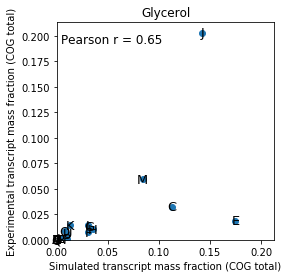

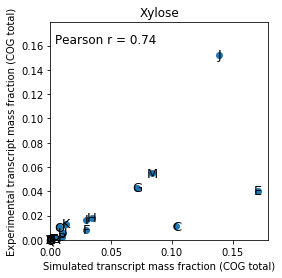

In [7]:
tx_summary = []

for substrate in ["Glucose", "Acetate", "Glycerol", "Xylose"]:
    sim = sim_tx[substrate].rename(columns={"Mass Fraction": "sim"})
    sim = sim.merge(cog_map, on="Gene", how="left")
    sim["COG"] = sim["COG"].fillna("Unknown")
    sim = sim[sim["COG"].astype(str).str.lower() != "unknown"]

    # Experimental: TPM mass-fraction-like
    exp_sub = tpm[["Gene", substrate]].rename(columns={substrate: "exp"})
    exp_sub = exp_sub.merge(cog_map, on="Gene", how="left")
    exp_sub["COG"] = exp_sub["COG"].fillna("Unknown")
    exp_sub = exp_sub[exp_sub["COG"].astype(str).str.lower() != "unknown"]

    # Intersection-only
    merged = exp_sub.merge(sim[["Gene", "COG", "sim"]], on=["Gene", "COG"], how="inner")

    agg = (
        merged
        .groupby("COG", as_index=False)
        .agg({
            "exp": "sum",
            "sim": "sum"
        })
        .rename(columns={
            "exp": "exp_total",
            "sim": "sim_total"
        })
    )

    r = plot_cog_scatter(
        agg_df=agg,
        cog_col="COG",
        title=substrate,
        xlab="Simulated transcript mass fraction (COG total)",
        ylab="Experimental transcript mass fraction (COG total)",
        label_font=13,
    )

    tx_summary.append({"Substrate": substrate, "Pearson_r": r, "N_COGs": len(agg)})

# pd.DataFrame(tx_summary)
